# End-to-End Machine Learning: Regression
## Predicting California House Prices

---

### What is Regression?

**Regression** is a supervised machine learning task where we predict a **continuous numerical value**.

Real-world examples:
- Predicting house prices
- Forecasting sales revenue
- Estimating delivery time

In this notebook, we predict the **median house value** of California districts.

---

### ML Pipeline We Will Follow

```
Load Data  -->  EDA  -->  Preprocessing  -->  Bias-Variance  -->  Cross-Validation
     -->  Train Models  -->  Hyperparameter Tuning  -->  Final Evaluation
```

---

### Dataset: California Housing (built into scikit-learn)

| Property | Value |
|----------|-------|
| Samples | 20,640 |
| Features | 8 |
| Target | Median house value (in units of $100,000) |

| Feature | Description |
|---------|-------------|
| MedInc | Median income in block group |
| HouseAge | Median house age in block group |
| AveRooms | Average rooms per household |
| AveBedrms | Average bedrooms per household |
| Population | Block group population |
| AveOccup | Average household members |
| Latitude | Block group latitude |
| Longitude | Block group longitude |

> **No download needed!** The dataset is bundled with scikit-learn and loads in seconds.

In [ ]:
# ================================================================
# IMPORTS
# All libraries below come pre-installed in Google Colab.
#
# numpy        : numerical computations (arrays, math)
# pandas       : data manipulation (think: programmable Excel)
# matplotlib   : base plotting library
# seaborn      : statistical visualization on top of matplotlib
# sklearn      : machine learning — models, metrics, utilities
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import fetch_california_housing

# Model selection utilities
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    GridSearchCV,
    learning_curve
)

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Visual style
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.dpi'] = 100

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Section 1: Load the Dataset

`fetch_california_housing()` returns a Bunch object (like a dictionary) with:
- `.data` : feature values (2D array)
- `.target` : house prices (1D array)
- `.feature_names` : names of the columns

We convert it to a **pandas DataFrame** — the standard tabular format for data science.

In [ ]:
# Load the dataset from scikit-learn
housing = fetch_california_housing()

# Create a DataFrame — easier to view and manipulate than raw arrays
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target  # Add the target column

print(f'Dataset shape: {df.shape}  ({df.shape[0]} rows, {df.shape[1]} columns)')
print(f'Features:      {list(df.columns[:-1])}')
print(f'Target:        MedHouseVal (median house value in $100,000 units)')
print(f"                e.g., a value of 2.5 means $250,000")
print()
df.head()

Dataset shape: (20640, 9)  (20640 rows, 9 columns)
Features:      ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target:        MedHouseVal (median house value in $100,000 units)
                e.g., a value of 2.5 means $250,000



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


---
## Section 2: Exploratory Data Analysis (EDA)

Before training any model, we **explore the data** to understand:
1. What the data looks like (types, shape, sample rows)
2. Statistical properties of each feature
3. Missing values
4. How features are distributed
5. How features relate to each other and the target

> EDA is not optional — it prevents surprises later and guides better feature engineering.

In [ ]:
# --- EDA Step 1: Data types and non-null counts ---
# df.info() shows:
#   - Column names
#   - Number of non-null values (helps spot missing values)
#   - Data type of each column (int, float, object, etc.)
print('=== DATASET INFO ===')
df.info()

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
# --- EDA Step 2: Statistical summary ---
# describe() gives count, mean, std, min, 25th/50th/75th percentiles, max
# This helps spot outliers, skewed distributions, and scale differences between features
print('=== STATISTICAL SUMMARY ===')
df.describe().round(2)

=== STATISTICAL SUMMARY ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


In [ ]:
# --- EDA Step 3: Check for missing values ---
# Missing values can cause model training to fail or produce bad results
# Strategies: drop rows, fill with mean/median/mode, use model-based imputation
print('=== MISSING VALUES CHECK ===')
missing = df.isnull().sum()

if missing.sum() == 0:
    print('Great news: no missing values found! This dataset is complete.')
else:
    print('Columns with missing values:')
    print(missing[missing > 0])

# Also check for duplicates
duplicates = df.duplicated().sum()
print(f'\nDuplicate rows: {duplicates}')

=== MISSING VALUES CHECK ===
Great news: no missing values found! This dataset is complete.

Duplicate rows: 0


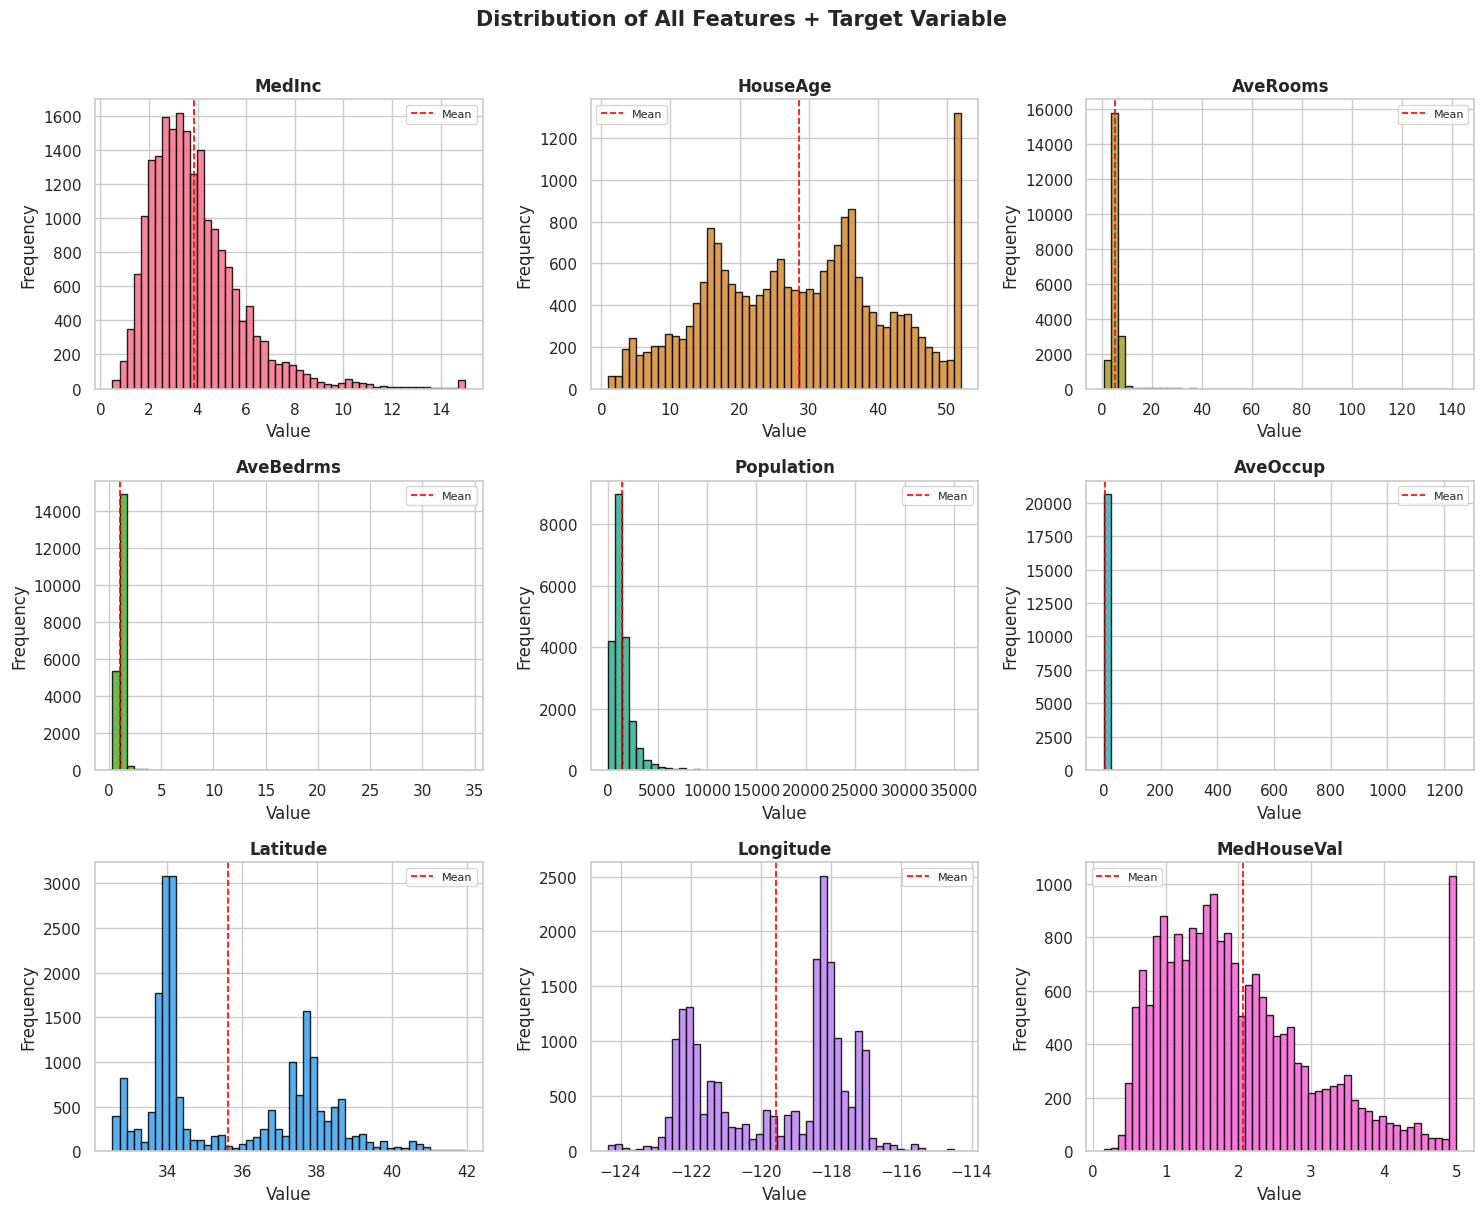

Observations:
  - MedInc and MedHouseVal are right-skewed (long tail on the right)
  - AveRooms and AveBedrms have outliers (extreme high values)
  - Latitude/Longitude show distinct geographic clusters


In [ ]:
# --- EDA Step 4: Feature distributions ---
# A histogram shows how values are spread across a column.
# Look for: skewed distributions, outliers, multiple peaks (bimodal)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
palette = sns.color_palette('husl', 9)

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=50, edgecolor='black', color=palette[i], alpha=0.85)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    # Add mean line
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.2, label='Mean')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution of All Features + Target Variable', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Observations:')
print('  - MedInc and MedHouseVal are right-skewed (long tail on the right)')
print('  - AveRooms and AveBedrms have outliers (extreme high values)')
print('  - Latitude/Longitude show distinct geographic clusters')

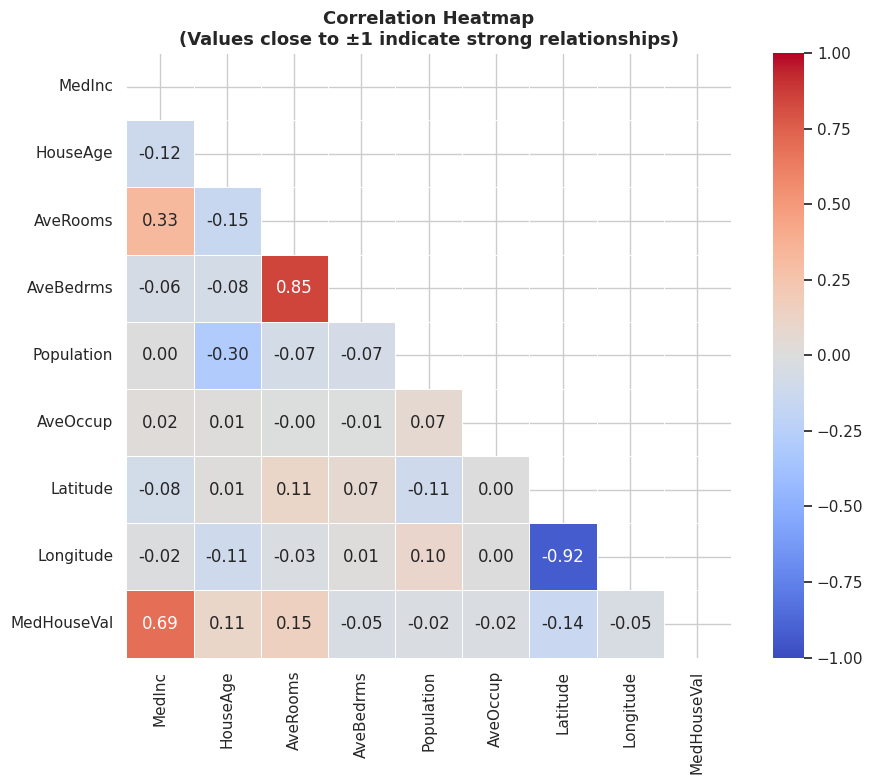

Correlation with target (MedHouseVal):
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160

Key insight: MedInc has the strongest positive correlation with house value!


In [ ]:
# --- EDA Step 5: Correlation heatmap ---
# Correlation measures how strongly two variables move together:
#   +1.0  = perfect positive correlation
#    0.0  = no linear relationship
#   -1.0  = perfect negative correlation
#
# For the target (MedHouseVal), higher absolute correlation = more predictive power

plt.figure(figsize=(10, 8))
corr = df.corr()

# mask=upper triangle to avoid duplicate info
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5,
    mask=mask, vmin=-1, vmax=1
)
plt.title('Correlation Heatmap\n(Values close to ±1 indicate strong relationships)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print correlations with target, sorted
print('Correlation with target (MedHouseVal):')
print(corr['MedHouseVal'].sort_values(ascending=False).to_string())
print('\nKey insight: MedInc has the strongest positive correlation with house value!')

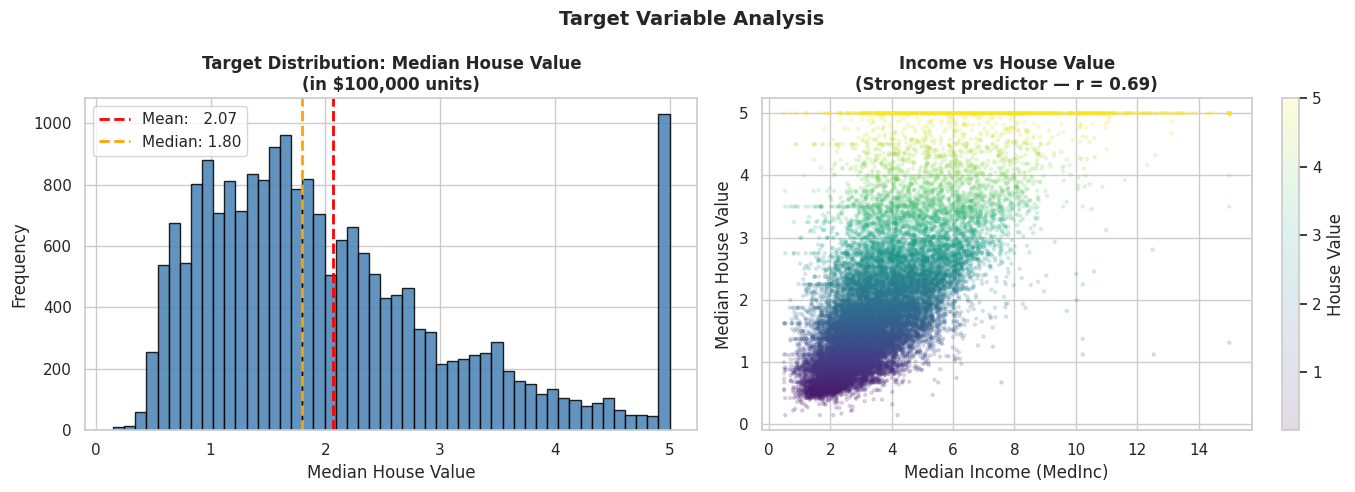

Notice the hard ceiling at 5.0 ($500,000) — data was capped at this value.
This is a data artifact worth noting. Real-world data often has quirks like this.


In [ ]:
# --- EDA Step 6: Target variable deep dive ---
# Understanding the target distribution is critical.
# A skewed target may benefit from log transformation before modeling.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution with mean and median markers
axes[0].hist(df['MedHouseVal'], bins=50, edgecolor='black', color='steelblue', alpha=0.85)
axes[0].axvline(df['MedHouseVal'].mean(), color='red', linestyle='--', lw=2,
                label=f'Mean:   {df["MedHouseVal"].mean():.2f}')
axes[0].axvline(df['MedHouseVal'].median(), color='orange', linestyle='--', lw=2,
                label=f'Median: {df["MedHouseVal"].median():.2f}')
axes[0].set_title('Target Distribution: Median House Value\n(in $100,000 units)', fontweight='bold')
axes[0].set_xlabel('Median House Value')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Scatter: strongest predictor vs target
sc = axes[1].scatter(df['MedInc'], df['MedHouseVal'],
                     alpha=0.15, s=5, c=df['MedHouseVal'], cmap='viridis')
plt.colorbar(sc, ax=axes[1], label='House Value')
axes[1].set_xlabel('Median Income (MedInc)')
axes[1].set_ylabel('Median House Value')
axes[1].set_title('Income vs House Value\n(Strongest predictor — r = 0.69)', fontweight='bold')

plt.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Notice the hard ceiling at 5.0 ($500,000) — data was capped at this value.')
print('This is a data artifact worth noting. Real-world data often has quirks like this.')

---
## Section 3: Data Preprocessing

Raw data must be prepared before feeding it to ML models:

### Step A: Train-Test Split
We split data into:
- **Training set (80%)** — the model learns from this
- **Test set (20%)** — held out, used only for final evaluation

> The test set simulates "new, unseen" data. If we evaluate on training data, we are cheating — the model has already seen it!

### Step B: Feature Scaling
Features like `MedInc` range from 0–15, while `Population` can be in the thousands. This scale mismatch can confuse models that rely on distances or gradient descent.

**StandardScaler** transforms each feature so that:
- Mean = 0
- Standard Deviation = 1

> **Critical rule:** Fit the scaler ONLY on training data, then use it to transform both train and test sets. Fitting on test data would "leak" information and give over-optimistic results.

In [ ]:
# --- Preprocessing Step A: Separate features and target, then split ---

X = df.drop('MedHouseVal', axis=1)  # Features (all columns except target)
y = df['MedHouseVal']               # Target variable

# Split: 80% for training, 20% for testing
# random_state=42 ensures we get the same split every time we run this (reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'Total samples:    {len(df)}')
print(f'Training samples: {len(X_train)}  ({len(X_train)/len(df):.0%})')
print(f'Test samples:     {len(X_test)}   ({len(X_test)/len(df):.0%})')
print(f'Number of features: {X_train.shape[1]}')

Total samples:    20640
Training samples: 16512  (80%)
Test samples:     4128   (20%)
Number of features: 8


In [ ]:
# --- Preprocessing Step B: Feature scaling using StandardScaler ---

scaler = StandardScaler()

# fit_transform on TRAINING data: learns mean and std from training, then scales it
X_train_scaled = scaler.fit_transform(X_train)

# transform (not fit_transform!) on TEST data: uses the same mean/std from training
X_test_scaled = scaler.transform(X_test)

print('StandardScaler applied!')
print(f'\nAfter scaling — training set statistics:')
print(f'  Mean: {X_train_scaled.mean():.6f}  (should be very close to 0)')
print(f'  Std:  {X_train_scaled.std():.6f}  (should be very close to 1)')

# Show before vs after for one feature
print(f'\nExample — MedInc before scaling: min={X_train["MedInc"].min():.2f}, max={X_train["MedInc"].max():.2f}')
print(f'Example — MedInc after  scaling: min={X_train_scaled[:,0].min():.2f}, max={X_train_scaled[:,0].max():.2f}')

StandardScaler applied!

After scaling — training set statistics:
  Mean: 0.000000  (should be very close to 0)
  Std:  1.000000  (should be very close to 1)

Example — MedInc before scaling: min=0.50, max=15.00
Example — MedInc after  scaling: min=-1.78, max=5.84


---
## Section 4: Bias-Variance Tradeoff

This is one of the most fundamental concepts in machine learning.

---

### The Dartboard Analogy

Imagine throwing darts at a dartboard. The **bullseye** is the true answer we want to predict.

| Type | Dart Pattern | What it Means |
|------|-------------|---------------|
| **High Bias** | Darts clustered far from center | Model is too simple — misses the pattern |
| **High Variance** | Darts scattered all over | Model memorizes training data — falls apart on new data |
| **Balanced** | Darts clustered near center | Just right! |

---

### In ML Terms

**Bias** = Error from **wrong assumptions**. The model is too simple to capture the true relationship.
- Symptom: High training error AND high validation error (both are bad)
- Called: **Underfitting**
- Fix: Use a more complex model, add features, reduce regularization

**Variance** = Error from **overfitting to noise**. The model memorizes the training data, including random noise.
- Symptom: Low training error but HIGH validation error (big gap)
- Called: **Overfitting**
- Fix: Use simpler model, add more data, increase regularization, use cross-validation

---

### Learning Curves

A **learning curve** plots training error and validation error as we increase the training set size.
- It's a diagnostic tool: tells you if your model is underfitting or overfitting.
- If both errors are high → underfitting (high bias)
- If training error is low but validation error is high → overfitting (high variance)
- If both errors converge at a low value → good model!

The code below plots learning curves for three scenarios.

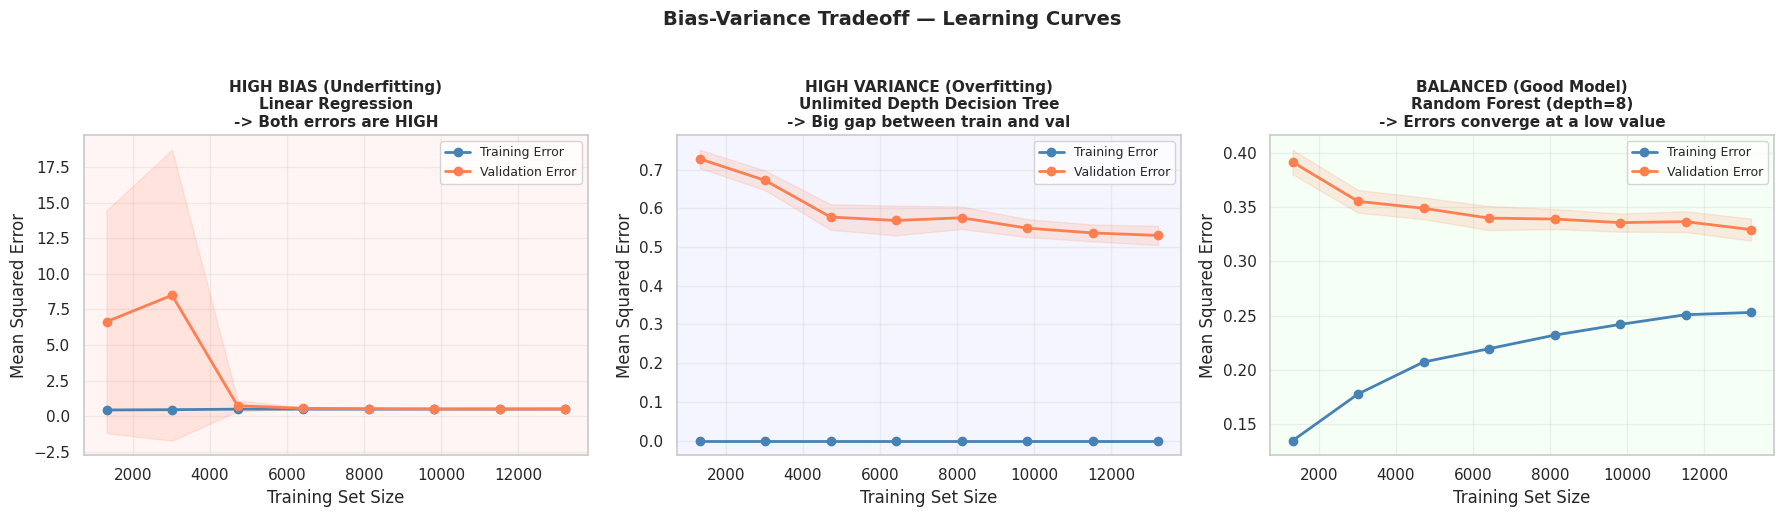

Summary:
  HIGH BIAS:     Both errors are high and close together  -> Underfitting
  HIGH VARIANCE: Training error low, validation error high -> Overfitting
  BALANCED:      Both errors low and converging            -> Good model!


In [ ]:
# --- Bias-Variance Tradeoff: Learning Curves ---
# We compare three models:
#   1. Linear Regression  -> too simple for this data -> HIGH BIAS (underfitting)
#   2. Deep Decision Tree -> too complex, memorizes noise -> HIGH VARIANCE (overfitting)
#   3. Shallow Random Forest -> good balance -> BALANCED

def plot_learning_curve(ax, estimator, X, y, title, bg_color='white'):
    """Plots training and validation error as training size increases."""
    sizes, train_scores, val_scores = learning_curve(
        estimator, X, y,
        cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 8),
        scoring='neg_mean_squared_error'
    )
    # Negate because sklearn returns negative MSE
    train_mean = -train_scores.mean(axis=1)
    val_mean   = -val_scores.mean(axis=1)
    val_std    =  val_scores.std(axis=1)

    ax.plot(sizes, train_mean, 'o-', color='steelblue', lw=2, ms=6, label='Training Error')
    ax.plot(sizes, val_mean,   'o-', color='coral',     lw=2, ms=6, label='Validation Error')
    ax.fill_between(sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='coral')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('Mean Squared Error')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_facecolor(bg_color)
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scenario 1: High Bias (Underfitting)
plot_learning_curve(
    axes[0], LinearRegression(), X_train_scaled, y_train,
    'HIGH BIAS (Underfitting)\nLinear Regression\n-> Both errors are HIGH',
    bg_color='#FFF5F5'
)

# Scenario 2: High Variance (Overfitting)
plot_learning_curve(
    axes[1], DecisionTreeRegressor(max_depth=None, random_state=42), X_train_scaled, y_train,
    'HIGH VARIANCE (Overfitting)\nUnlimited Depth Decision Tree\n-> Big gap between train and val',
    bg_color='#F5F5FF'
)

# Scenario 3: Balanced
plot_learning_curve(
    axes[2], RandomForestRegressor(n_estimators=50, max_depth=8, random_state=42), X_train_scaled, y_train,
    'BALANCED (Good Model)\nRandom Forest (depth=8)\n-> Errors converge at a low value',
    bg_color='#F5FFF5'
)

plt.suptitle('Bias-Variance Tradeoff — Learning Curves', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print('Summary:')
print('  HIGH BIAS:     Both errors are high and close together  -> Underfitting')
print('  HIGH VARIANCE: Training error low, validation error high -> Overfitting')
print('  BALANCED:      Both errors low and converging            -> Good model!')

---
## Section 5: Cross-Validation

### The Problem with a Single Train-Test Split

If you evaluate your model on just one test set:
- The result depends on **which samples randomly ended up in the test set** (luck!)
- You might accidentally get an easy or hard test set
- You are "wasting" data — test samples never contribute to training

---

### Solution: K-Fold Cross-Validation

Instead of one split, do **K splits** and average the results:

```
Data: [  Fold 1  |  Fold 2  |  Fold 3  |  Fold 4  |  Fold 5  ]

Round 1: Train on [2,3,4,5], Validate on [1] -> score_1
Round 2: Train on [1,3,4,5], Validate on [2] -> score_2
Round 3: Train on [1,2,4,5], Validate on [3] -> score_3
Round 4: Train on [1,2,3,5], Validate on [4] -> score_4
Round 5: Train on [1,2,3,4], Validate on [5] -> score_5

Final score = mean(score_1, score_2, score_3, score_4, score_5)
```

### Why Cross-Validation is Essential:
- **More reliable** estimate of how the model generalizes
- Every sample is used for both training AND validation (just not at the same time)
- Returns mean ± std: the std tells you how stable the model is
- Standard practice in industry and ML competitions

> We use cross-validation during model development on the **training set only**. The test set is still kept completely separate for the final evaluation.

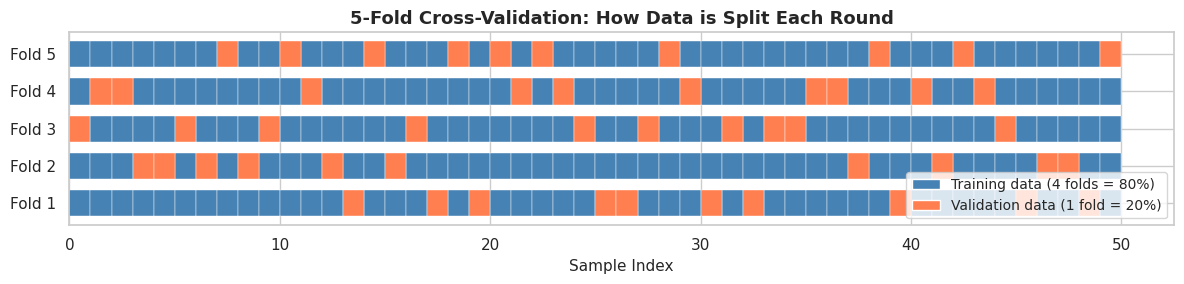


--- Running 5-Fold Cross-Validation on Linear Regression ---

  Fold 1: R² = 0.6201
  Fold 2: R² = 0.6130
  Fold 3: R² = 0.6134
  Fold 4: R² = 0.6107
  Fold 5: R² = 0.6002

Mean CV R²: 0.6115
Std  CV R²: 0.0065

Interpretation: R² of 0.6115 means the model explains
61.1% of the variance in house prices.
The ±0.0065 tells us how consistent it is across folds.


In [ ]:
# --- Cross-Validation Visualization + Demo ---

# PART 1: Visualize how 5-Fold CV splits the data
fig, ax = plt.subplots(figsize=(12, 3))
n_vis = 50  # show 50 sample slots for clarity
kf_vis = KFold(n_splits=5, shuffle=True, random_state=42)

for fold_num, (train_idx, val_idx) in enumerate(kf_vis.split(range(n_vis))):
    for j in train_idx:
        ax.barh(fold_num, 1, left=j, color='steelblue', height=0.7,
                edgecolor='white', linewidth=0.3)
    for j in val_idx:
        ax.barh(fold_num, 1, left=j, color='coral', height=0.7,
                edgecolor='white', linewidth=0.3)

ax.set_yticks(range(5))
ax.set_yticklabels([f'Fold {i+1}' for i in range(5)], fontsize=11)
ax.set_xlabel('Sample Index', fontsize=11)
ax.set_title('5-Fold Cross-Validation: How Data is Split Each Round', fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='Training data (4 folds = 80%)'),
    Patch(facecolor='coral',     label='Validation data (1 fold = 20%)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()


# PART 2: Run cross_val_score on Linear Regression
print('\n--- Running 5-Fold Cross-Validation on Linear Regression ---\n')
lr = LinearRegression()
cv_scores = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='r2')

for i, score in enumerate(cv_scores):
    print(f'  Fold {i+1}: R² = {score:.4f}')

print(f'\nMean CV R²: {cv_scores.mean():.4f}')
print(f'Std  CV R²: {cv_scores.std():.4f}')
print(f'\nInterpretation: R² of {cv_scores.mean():.4f} means the model explains')
print(f'{cv_scores.mean()*100:.1f}% of the variance in house prices.')
print(f'The ±{cv_scores.std():.4f} tells us how consistent it is across folds.')

---
## Section 6: Training Multiple Models

We never train just one model and call it done. Instead, we **compare multiple algorithms** using cross-validation, then invest time tuning the best one.

### Models We Will Train:

| Model | Type | Characteristics |
|-------|------|-----------------|
| Linear Regression | Linear | Fast, interpretable, assumes linear relationship |
| Ridge (L2) | Linear + Regularization | Penalizes large coefficients, reduces overfitting |
| Lasso (L1) | Linear + Regularization | Can zero out unimportant features (feature selection) |
| Decision Tree | Non-linear | Easy to interpret, but tends to overfit |
| Random Forest | Ensemble | Many trees combined — very powerful, robust |
| Gradient Boosting | Ensemble | Trees built sequentially, correcting errors — often best |

### Metrics We Will Use:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **R²** | Var explained / Total var | 1.0 = perfect, 0.0 = constant baseline |
| **RMSE** | sqrt(mean((y - ŷ)²)) | Error in the same units as target, penalizes large errors |

In [ ]:
# --- Train and Evaluate Multiple Models Using 5-Fold CV ---

# Define all models to compare
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (L2)':        Ridge(alpha=1.0),
    'Lasso (L1)':        Lasso(alpha=0.1),
    'Decision Tree':     DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []
print('Training models with 5-Fold Cross-Validation...\n')
print(f'{"Model":<22} | {"CV R²":>10} | {"CV R² Std":>10} | {"CV RMSE":>10}')
print('-' * 60)

for name, model in models.items():
    # R² score (higher is better)
    cv_r2 = cross_val_score(
        model, X_train_scaled, y_train, cv=5, scoring='r2'
    )
    # RMSE score (lower is better)
    cv_rmse = np.sqrt(-cross_val_score(
        model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error'
    ))

    results.append({
        'Model':    name,
        'CV R2':    cv_r2.mean(),
        'R2 Std':   cv_r2.std(),
        'CV RMSE':  cv_rmse.mean()
    })
    print(f'{name:<22} | {cv_r2.mean():>10.4f} | {cv_r2.std():>10.4f} | {cv_rmse.mean():>10.4f}')

results_df = pd.DataFrame(results).sort_values('CV R2', ascending=False).reset_index(drop=True)
print(f'\n=== Ranked by CV R² (higher is better) ===')
print(results_df.to_string(index=False))

Training models with 5-Fold Cross-Validation...

Model                  |      CV R² |  CV R² Std |    CV RMSE
------------------------------------------------------------
Linear Regression      |     0.6115 |     0.0065 |     0.7205
Ridge (L2)             |     0.6115 |     0.0065 |     0.7205
Lasso (L1)             |     0.4971 |     0.0041 |     0.8198
Decision Tree          |     0.6570 |     0.0162 |     0.6768
Random Forest          |     0.8042 |     0.0053 |     0.5115
Gradient Boosting      |     0.7866 |     0.0032 |     0.5340

=== Ranked by CV R² (higher is better) ===
            Model    CV R2   R2 Std  CV RMSE
    Random Forest 0.804169 0.005324 0.511458
Gradient Boosting 0.786592 0.003211 0.534012
    Decision Tree 0.656954 0.016188 0.676832
Linear Regression 0.611484 0.006467 0.720527
       Ridge (L2) 0.611484 0.006460 0.720527
       Lasso (L1) 0.497094 0.004081 0.819769


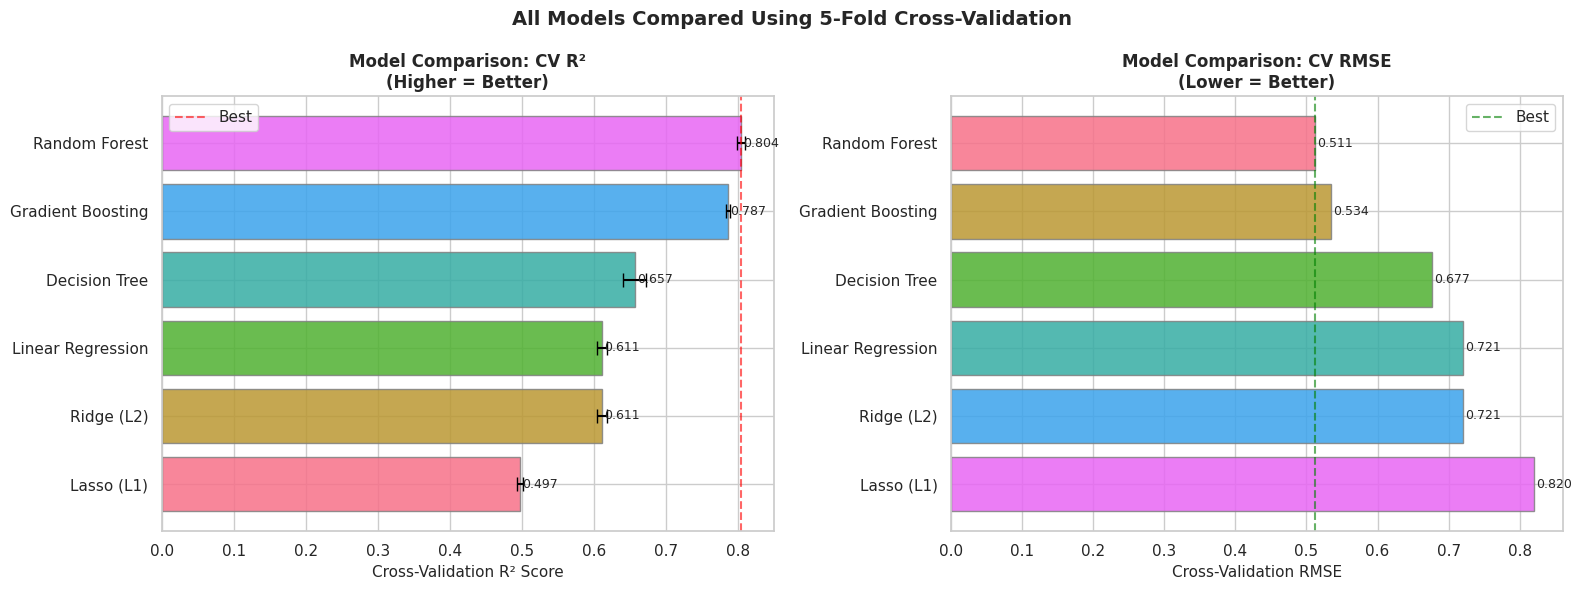

Best model: Random Forest (CV R² = 0.8042)
We will now tune this model further with hyperparameter search.


In [ ]:
# --- Model Comparison Charts ---

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = sns.color_palette('husl', len(results_df))

# Sort for consistent display
sorted_r2   = results_df.sort_values('CV R2')
sorted_rmse = results_df.sort_values('CV RMSE', ascending=False)

# Chart 1: CV R² (higher is better)
bars = axes[0].barh(
    sorted_r2['Model'], sorted_r2['CV R2'],
    xerr=sorted_r2['R2 Std'],
    color=colors, alpha=0.85, capsize=5, edgecolor='gray'
)
axes[0].set_xlabel('Cross-Validation R² Score', fontsize=11)
axes[0].set_title('Model Comparison: CV R²\n(Higher = Better)', fontsize=12, fontweight='bold')
axes[0].axvline(x=sorted_r2['CV R2'].max(), color='red', linestyle='--', alpha=0.6, label='Best')
for bar, val in zip(bars, sorted_r2['CV R2']):
    axes[0].text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
axes[0].legend()

# Chart 2: CV RMSE (lower is better)
bars2 = axes[1].barh(
    sorted_rmse['Model'], sorted_rmse['CV RMSE'],
    color=colors[::-1], alpha=0.85, edgecolor='gray'
)
axes[1].set_xlabel('Cross-Validation RMSE', fontsize=11)
axes[1].set_title('Model Comparison: CV RMSE\n(Lower = Better)', fontsize=12, fontweight='bold')
axes[1].axvline(x=sorted_rmse['CV RMSE'].min(), color='green', linestyle='--', alpha=0.6, label='Best')
for bar, val in zip(bars2, sorted_rmse['CV RMSE']):
    axes[1].text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
axes[1].legend()

plt.suptitle('All Models Compared Using 5-Fold Cross-Validation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]['Model']
print(f'Best model: {best_model_name} (CV R² = {results_df.iloc[0]["CV R2"]:.4f})')
print('We will now tune this model further with hyperparameter search.')

---
## Section 7: Hyperparameter Tuning with GridSearchCV

### What are Hyperparameters?

ML models have two types of parameters:

| Type | Example | Who sets it? |
|------|---------|-------------|
| **Parameters** | Tree split thresholds, linear coefficients | Learned from data during training |
| **Hyperparameters** | `n_estimators`, `max_depth`, `learning_rate` | Set by YOU before training |

Hyperparameters control the model's behavior and complexity. Choosing them well is crucial.

---

### GridSearchCV: Exhaustive Search

GridSearchCV tries **every combination** of hyperparameters from a grid, evaluating each with cross-validation:

```
n_estimators=[50, 100, 200]  x  max_depth=[None, 5, 10, 15]  x  min_samples_split=[2, 5, 10]
= 3 x 4 x 3 = 36 combinations  x  5-fold CV  = 180 model fits
```

The combination with the best mean CV score is returned as `best_params_`.

> Tip: If the grid is too large, use `RandomizedSearchCV` instead — it randomly samples combinations, which is faster and often finds a good result.

In [ ]:
# --- Hyperparameter Tuning: GridSearchCV on Random Forest ---

# Define the grid of hyperparameters to search
# Each key is a hyperparameter name, value is a list of options to try
param_grid = {
    'n_estimators':      [50, 100, 200],     # number of trees
    'max_depth':         [None, 5, 10, 15],  # max depth of each tree
    'min_samples_split': [2, 5, 10]          # min samples needed to split a node
}

n_combos = 3 * 4 * 3
print(f'Parameter combinations to try: {n_combos}')
print(f'With 5-fold CV: {n_combos * 5} model fits total')
print('This may take 1-3 minutes...\n')

# GridSearchCV wraps the model and evaluates each combination using CV
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,    # use all CPU cores for speed
    verbose=1     # print progress
)

grid_search.fit(X_train_scaled, y_train)

print(f'\n=== RESULTS ===')
print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best CV R²:      {grid_search.best_score_:.4f}')

# Top 5 combinations
cv_results = pd.DataFrame(grid_search.cv_results_)
top5 = cv_results.nlargest(5, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']]
print('\nTop 5 parameter combinations:')
print(top5.to_string(index=False))

Parameter combinations to try: 36
With 5-fold CV: 180 model fits total
This may take 1-3 minutes...

Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== RESULTS ===
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R²:      0.8049

Top 5 parameter combinations:
                                                          params  mean_test_score  std_test_score
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}         0.804880        0.005140
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}         0.804676        0.004865
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}         0.804222        0.004908
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}         0.804169        0.005324
  {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}         0.802951        0.005149


---
## Section 8: Final Model Evaluation

Now we use the best model from hyperparameter tuning to make predictions on the **test set** — data the model has never seen.

### Regression Metrics Explained

| Metric | What it measures | Better when |
|--------|-----------------|-------------|
| **MAE** (Mean Absolute Error) | Average absolute difference between predicted and actual | Lower |
| **RMSE** (Root Mean Squared Error) | Like MAE but penalizes large errors more | Lower |
| **R²** (R-squared) | % of variance in target explained by the model | Higher (max = 1.0) |

### Visualization: Actual vs Predicted

A scatter plot of **actual values vs predicted values** is the go-to visualization for regression:
- Perfect model: all points on the diagonal line y = x
- More scatter = worse predictions

### Residual Plot

A **residual** is the error: `actual - predicted`
- Good model: residuals randomly scattered around 0 (no pattern)
- Bad model: patterns in residuals mean the model is missing something systematic

In [ ]:
# --- Final Evaluation on the Test Set ---

# Use the best model found by GridSearchCV
best_model = grid_search.best_estimator_

# Predict on the test set (data the model has NEVER seen)
y_pred = best_model.predict(X_test_scaled)

# Compute metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=' * 55)
print('        FINAL PERFORMANCE ON TEST SET')
print('=' * 55)
print(f'  MAE  (Mean Absolute Error):  {mae:.4f}')
print(f'  RMSE (Root Mean Sq Error):   {rmse:.4f}')
print(f'  R²   (R-squared):            {r2:.4f}')
print('=' * 55)
print(f'\nPlain English:')
print(f'  -> R² = {r2:.4f} means our model explains {r2*100:.1f}% of the')
print(f'     variance in California house prices.')
print(f'  -> MAE = {mae:.4f} means on average predictions are off')
print(f'     by ~${mae * 100_000:,.0f}')

        FINAL PERFORMANCE ON TEST SET
  MAE  (Mean Absolute Error):  0.3268
  RMSE (Root Mean Sq Error):   0.5038
  R²   (R-squared):            0.8063

Plain English:
  -> R² = 0.8063 means our model explains 80.6% of the
     variance in California house prices.
  -> MAE = 0.3268 means on average predictions are off
     by ~$32,675


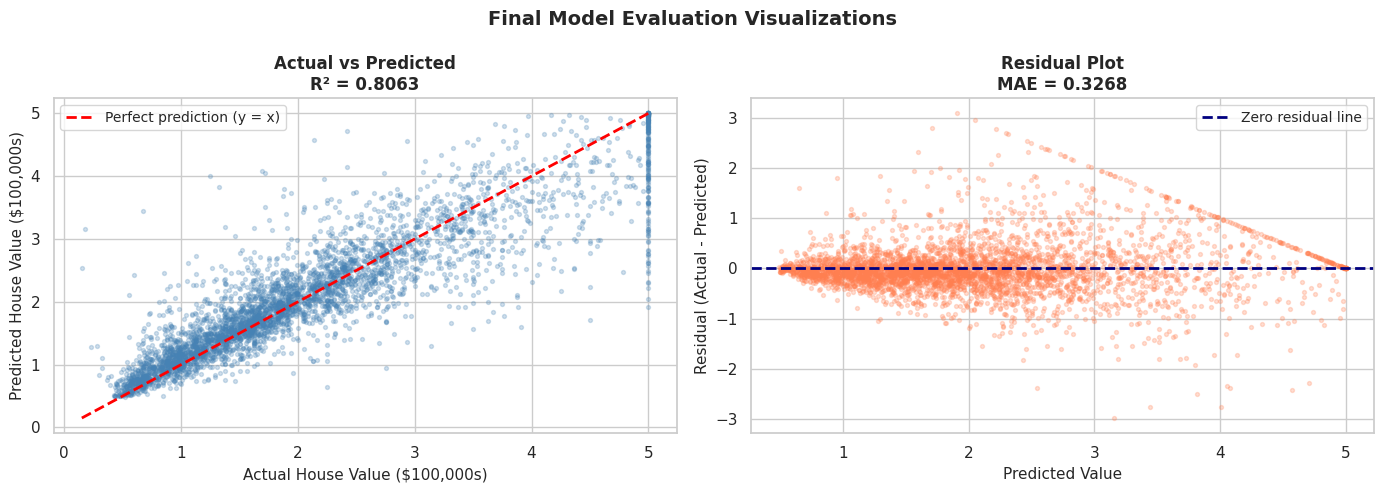

Residual plot interpretation:
  GOOD: Points randomly scattered around y=0 with no visible pattern
  BAD:  Fan shape (variance increases), or a curve (missing non-linear relationship)


In [ ]:
# --- Actual vs Predicted Plot + Residual Plot ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
residuals = y_test - y_pred

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.25, s=8, color='steelblue')
lims = [min(float(y_test.min()), y_pred.min()), max(float(y_test.max()), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Perfect prediction (y = x)')
axes[0].set_xlabel('Actual House Value ($100,000s)', fontsize=11)
axes[0].set_ylabel('Predicted House Value ($100,000s)', fontsize=11)
axes[0].set_title(f'Actual vs Predicted\nR² = {r2:.4f}', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

# Plot 2: Residual plot
axes[1].scatter(y_pred, residuals, alpha=0.25, s=8, color='coral')
axes[1].axhline(y=0, color='navy', linestyle='--', lw=2, label='Zero residual line')
axes[1].set_xlabel('Predicted Value', fontsize=11)
axes[1].set_ylabel('Residual (Actual - Predicted)', fontsize=11)
axes[1].set_title(f'Residual Plot\nMAE = {mae:.4f}', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Final Model Evaluation Visualizations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Residual plot interpretation:')
print('  GOOD: Points randomly scattered around y=0 with no visible pattern')
print('  BAD:  Fan shape (variance increases), or a curve (missing non-linear relationship)')

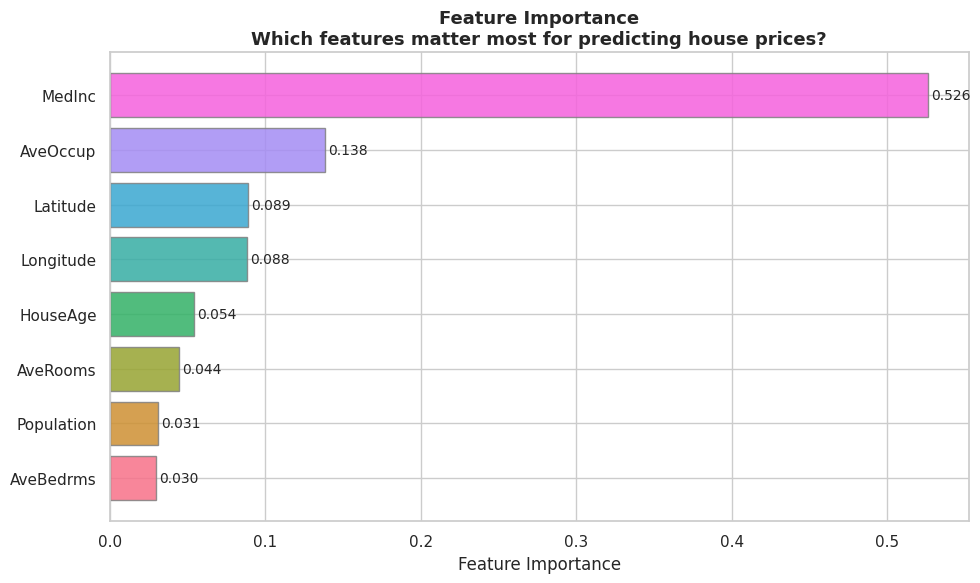

Most important feature: MedInc (importance = 0.526)
This matches our EDA finding — income is the strongest predictor of house price!


In [ ]:
# --- Feature Importance ---
# Random Forest computes feature importance based on how much each feature
# reduces impurity (error) across all trees on average.
# Higher importance = more useful for prediction.

feat_imp = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
colors = sns.color_palette('husl', len(feat_imp))
bars = plt.barh(feat_imp['Feature'], feat_imp['Importance'],
                color=colors, alpha=0.85, edgecolor='gray')

for bar, val in zip(bars, feat_imp['Importance']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

plt.xlabel('Feature Importance', fontsize=12)
plt.title('Feature Importance\nWhich features matter most for predicting house prices?',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

top_feature = feat_imp.iloc[-1]
print(f'Most important feature: {top_feature["Feature"]} (importance = {top_feature["Importance"]:.3f})')
print(f"This matches our EDA finding — income is the strongest predictor of house price!")

---
## Summary: What We Covered

### Full Regression Pipeline

| Step | What We Did | Key Takeaway |
|------|------------|---------------|
| 1. Load Data | `fetch_california_housing()` | Dataset ready in 1 line |
| 2. EDA | `.info()`, `.describe()`, heatmap, histograms | Always explore before modeling |
| 3. Preprocessing | Train-test split + StandardScaler | Fit scaler on train only! |
| 4. Bias-Variance | Learning curves for 3 models | Diagnose under/overfitting |
| 5. Cross-Validation | K-Fold CV for all models | More reliable than single split |
| 6. Model Comparison | 6 models, ranked by CV R² | Ensemble models win here |
| 7. Hyperparameter Tuning | GridSearchCV on best model | Tune the winner, not all models |
| 8. Final Evaluation | MAE, RMSE, R², residual plot | Always test on held-out set |

---

### Key Numbers to Remember

```
Final Test R²   ≈ 0.81  (model explains ~81% of variance)
Final Test RMSE ≈ 0.47  (error of ~$47,000 on average)
```

---

### What's Next?

See **Notebook 2** for the same dataset but framed as a **Classification** problem:  
→ Predict whether a house is *Expensive* or *Affordable*

---
## Summary: What We Covered

### Full Regression Pipeline

| Step | What We Did | Key Takeaway |
|------|------------|---------------|
| 1. Load Data | `fetch_california_housing()` | Dataset ready in 1 line |
| 2. EDA | `.info()`, `.describe()`, heatmap, histograms | Always explore before modeling |
| 3. Preprocessing | Train-test split + StandardScaler | Fit scaler on train only! |
| 4. Bias-Variance | Learning curves for 3 models | Diagnose under/overfitting |
| 5. Cross-Validation | K-Fold CV for all models | More reliable than single split |
| 6. Model Comparison | 6 models, ranked by CV R² | Ensemble models win here |
| 7. Hyperparameter Tuning | GridSearchCV on best model | Tune the winner, not all models |
| 8. Final Evaluation | MAE, RMSE, R², residual plot | Always test on held-out set |

---

### Key Numbers to Remember

```
Final Test R²   ≈ 0.81  (model explains ~81% of variance)
Final Test RMSE ≈ 0.47  (error of ~$47,000 on average)
```

---

### What's Next?

See **Notebook 2** for the same dataset but framed as a **Classification** problem:  
→ Predict whether a house is *Expensive* or *Affordable*